**G05**: Jakober, Matzinger, Winkler, Salzmann

In [21]:
import matplotlib.pyplot as plt
import torch

import torch.nn.functional as F

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm

from FTP_DeLearn.Week07.grad_cam_cnn import optimizer
from transformers import AltCLIPVisionModel

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device is set to: {device}")

Device is set to: cuda


# Get CIFAR dataset
Load from previous week

In [4]:
Transform = transforms.ToTensor()
train_data = datasets.CIFAR10(
    root = '../DL-PW-04/data',
    train = True,
    transform = Transform,
    download = True,
)

test_data = datasets.CIFAR10(
    root = '../DL-PW-04/data',
    train = False,
    transform = Transform,
    download = True
)

In [5]:
train_data

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ../DL-PW-04/data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [6]:
test_data

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: ../DL-PW-04/data
    Split: Test
    StandardTransform
Transform: ToTensor()

Size: torch.Size([3, 32, 32]) Label: 6


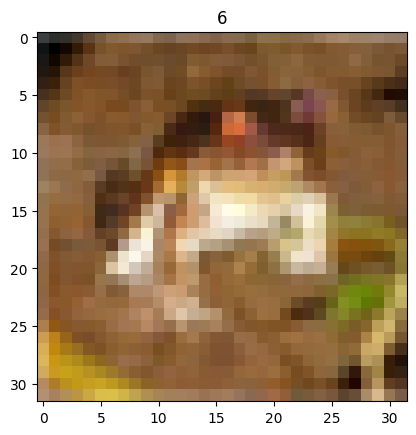

In [9]:
#Plot one train_data
img, target = train_data[0]
print('Size:', img.size(), 'Label:', target)
plt.imshow(img.permute(1, 2, 0)) # to fix the TypeError: Invalid shape (3, 32, 32) for image data
plt.title('%i' % target)
plt.show()

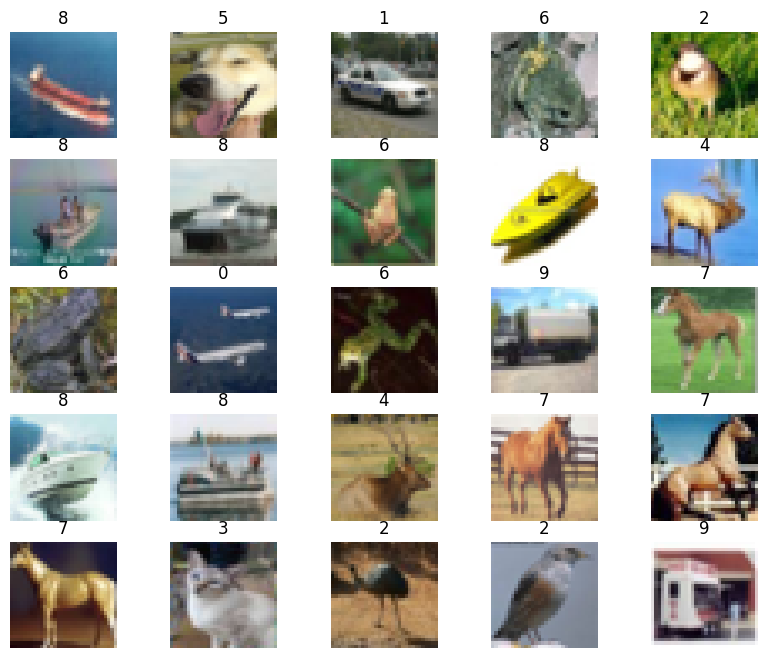

In [10]:
# Plot multiple train_data
def show_imgs(X):
    figure = plt.figure(figsize=(10, 8))
    cols, rows = 5, 5
    for i in range(1, cols * rows + 1):
        sample_idx = torch.randint(len(X), size=(1,)).item()
        img, label = X[sample_idx]
        figure.add_subplot(rows, cols, i)
        plt.title(label)
        plt.axis("off")
        plt.imshow(img.permute(1,2,0))
    plt.show()

show_imgs(train_data)

## Create Data Loaders

In [13]:
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=True)

# Building the Network

In [32]:
class NonSeqCNN(nn.Module):
    def __init__(self):
        super(NonSeqCNN, self).__init__()
        # Path 1
        self.conv2d_1_1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding="same")
        self.conv2d_1_2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding="same")

        # Path 2
        self.conv2d_2_1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding="same")
        self.conv2d_2_2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding="same")

        self.maxpool = nn.MaxPool2d(2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(8*8*64*2, 2048)
        self.fc2 = nn.Linear(2048, 10)

    def forward(self, x):
        x_1 = F.relu(self.conv2d_1_1(x))
        x_1 = self.maxpool(x_1)
        x_1 = F.relu(self.conv2d_1_2(x_1))
        x_1 = self.maxpool(x_1)
        x_1 = self.flatten(x_1)

        x_2 = F.relu(self.conv2d_2_1(x))
        x_2 = self.maxpool(x_2)
        x_2 = F.relu(self.conv2d_2_2(x_2))
        x_2 = self.maxpool(x_2)
        x_2 = self.flatten(x_2)

        x = torch.cat((x_1, x_2), 1)
        x = self.fc1(x)
        x = self.fc2(x)
        return x

In [51]:
def plot_results(train_losses, val_losses, train_accs, val_accs, total_targets, total_preds):
    fig, ax = plt.subplots(1, 3, figsize=(18, 4))

    ax[0].plot(train_losses, label='Training loss')
    ax[0].plot(val_losses, label='Val loss')
    ax[0].set_title(f"Loss")
    ax[0].legend()
    ax[0].grid()

    ax[1].plot(train_accs, label='Training acc')
    ax[1].plot(val_accs, label='Val acc')
    ax[1].set_title(f"Accuracy")
    ax[1].legend()
    ax[1].grid()

    cm = confusion_matrix(torch.cat(total_targets), torch.cat(total_preds))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax[2], cmap="Blues")

    plt.show()

# Train Loop

In [36]:
def run_epoch(model, dataloader, optimizer, criterion, train=True):
    """
    Runs one epoch for training or validation.
    """
    epoch_loss = 0
    correct = 0
    total_samples = len(dataloader.dataset)
    total_preds = []
    total_targets = []

    if train:
        model.train()
    else:
        model.eval()

    for X, y in tqdm(dataloader, desc=f"{'Train' if train else 'Val'}-Batch"):
        X, y = X.to(device), y.to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            output = model(X)
            loss = criterion(output, y.long().squeeze())

        epoch_loss += loss.item()
        _, y_pred = torch.max(output, dim=1)
        correct += torch.sum(y_pred == y).item()

        if train:
            loss.backward()
            optimizer.step()
        else:
            total_preds.append(y_pred.detach().cpu())
            total_targets.append(y.detach().cpu())

    avg_loss = epoch_loss / len(dataloader)
    accuracy = correct / total_samples

    return avg_loss, accuracy, total_preds, total_targets

def trainer(model, train_loader, val_loader, optimizer, criterion, n_epochs):
    """
    Trains and evaluates the model for n_epochs.
    """
    epoch_train_losses = []
    epoch_val_losses = []
    epoch_train_accs = []
    epoch_val_accs = []
    total_preds, total_targets = None, None

    for _ in range(n_epochs):
        train_loss, train_acc, _, _ = run_epoch(model, train_loader, optimizer, criterion, train=True)
        val_loss, val_acc, total_preds, total_targets = run_epoch(model, val_loader, optimizer, criterion, train=False)

        epoch_train_losses.append(train_loss)
        epoch_val_losses.append(val_loss)
        epoch_train_accs.append(train_acc)
        epoch_val_accs.append(val_acc)

    return epoch_train_losses, epoch_val_losses, epoch_train_accs, epoch_val_accs, total_preds, total_targets

In [54]:
num_epochs = 10

criterion = nn.CrossEntropyLoss()

model = NonSeqCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses, train_accs, val_accs, total_preds, total_targets = trainer(model, train_loader, test_loader, optimizer, criterion, num_epochs)

Val-Batch: 100%|██████████| 79/79 [00:01<00:00, 40.58it/s]


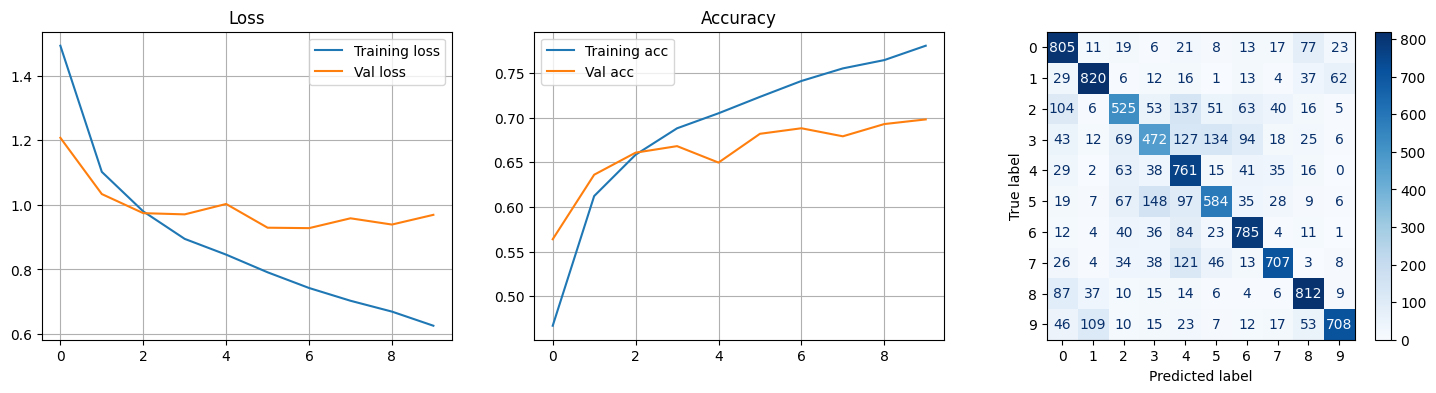

In [55]:
plot_results(train_losses, val_losses, train_accs, val_accs, total_targets, total_preds)

In [56]:
class SimpleNonSeqCNN(nn.Module):
    def __init__(self):
        super(SimpleNonSeqCNN, self).__init__()
        # Path 1
        self.conv2d_1_1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding="same")

        # Path 2
        self.conv2d_2_1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding="same")

        self.maxpool = nn.MaxPool2d(2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(16*16*32*2, 10)

    def forward(self, x):
        x_1 = F.relu(self.conv2d_1_1(x))
        x_1 = self.maxpool(x_1)
        x_1 = self.flatten(x_1)

        x_2 = F.relu(self.conv2d_2_1(x))
        x_2 = self.maxpool(x_2)
        x_2 = self.flatten(x_2)

        x = torch.cat((x_1, x_2), 1)
        x = self.fc1(x)
        return x

In [57]:
num_epochs = 10

criterion = nn.CrossEntropyLoss()

simple_model = SimpleNonSeqCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses, train_accs, val_accs, total_preds, total_targets = trainer(simple_model, train_loader, test_loader, optimizer, criterion, num_epochs)

Val-Batch: 100%|██████████| 79/79 [00:01<00:00, 41.57it/s]


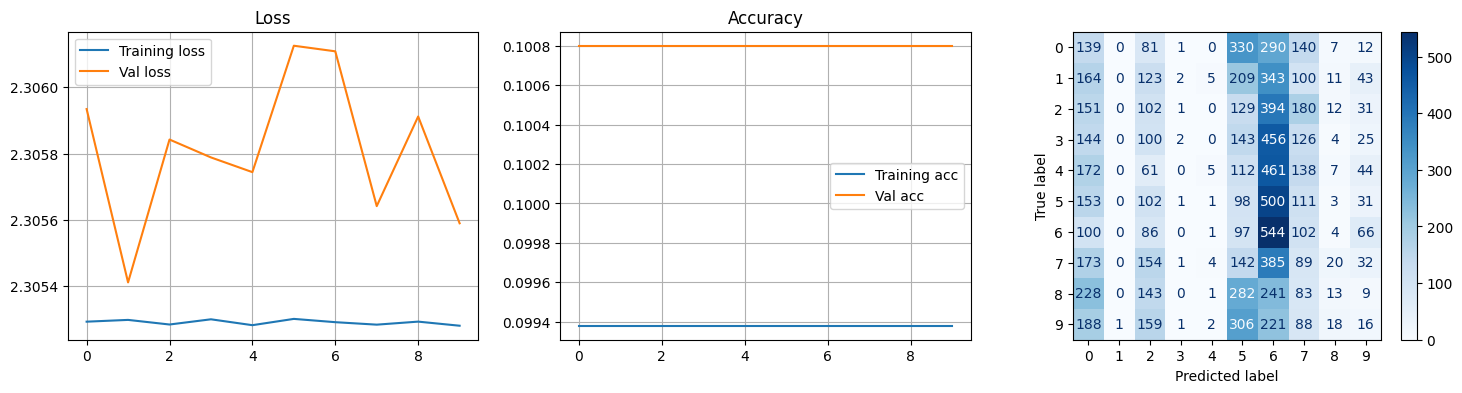

In [58]:
plot_results(train_losses, val_losses, train_accs, val_accs, total_targets, total_preds)

# Findings
To simple of a model to learn anything

In [49]:
class AdvNonSeqCNN(nn.Module):
    def __init__(self):
        super(AdvNonSeqCNN, self).__init__()
        # Path 1
        self.conv2d_1_1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding="same")
        self.conv2d_1_2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding="same")
        self.conv2d_1_3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding="same")

        # Path 2
        self.conv2d_2_1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding="same")
        self.conv2d_2_2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding="same")
        self.conv2d_2_3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding="same")

        self.maxpool = nn.MaxPool2d(2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(4*4*128*2, 2048)
        self.fc2 = nn.Linear(2048, 512)
        self.fc3 = nn.Linear(512, 10)

    def forward(self, x):
        x_1 = F.relu(self.conv2d_1_1(x))
        x_1 = self.maxpool(x_1)
        x_1 = F.relu(self.conv2d_1_2(x_1))
        x_1 = self.maxpool(x_1)
        x_1 = F.relu(self.conv2d_1_3(x_1))
        x_1 = self.maxpool(x_1)
        x_1 = self.flatten(x_1)

        x_2 = F.relu(self.conv2d_2_1(x))
        x_2 = self.maxpool(x_2)
        x_2 = F.relu(self.conv2d_2_2(x_2))
        x_2 = self.maxpool(x_2)
        x_2 = F.relu(self.conv2d_2_3(x_2))
        x_2 = self.maxpool(x_2)
        x_2 = self.flatten(x_2)

        x = torch.cat((x_1, x_2), 1)
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        return x

In [50]:
num_epochs = 10

criterion = nn.CrossEntropyLoss()

adv_model = AdvNonSeqCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses, val_losses, train_accs, val_accs, total_preds, total_targets = trainer(adv_model, train_loader, test_loader, optimizer, criterion, num_epochs)

Val-Batch: 100%|██████████| 79/79 [00:01<00:00, 40.83it/s]


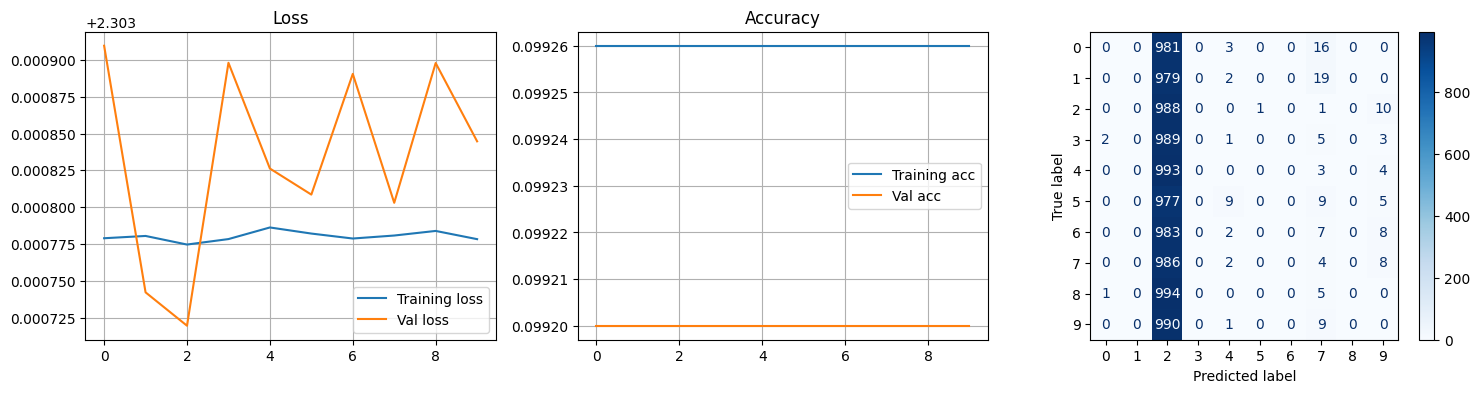

In [52]:
plot_results(train_losses, val_losses, train_accs, val_accs, total_targets, total_preds)